In [1]:
import numpy as np
import matplotlib.pyplot as plt

1. Разработать алгоритм моделирования нормально распределенного случайного вектора с заданными математическим
ожиданием и корреляционной матрицей (3 вариант).

In [2]:
M1 = np.array([[0], [0]])

M2 = np.array([[-1], [1]])

M3 = np.array([[-1], [-1]])

In [3]:
def generate_path_E_CTL(a = 0, b = 1):
    N = 1000
    X = np.random.uniform(a, b, N)
    
    sum_n = np.sum(X)
    mean_x = (b + a) / 2
    var = (b - a)**2 / 12

    return (sum_n -  N * mean_x) / np.sqrt(N * var)

E = np.array([[generate_path_E_CTL()], [generate_path_E_CTL()]])
E

array([[0.48619225],
       [1.1639566 ]])

In [4]:
B = np.array([[0.6, 0.5], 
             [0.5, 0.7]])

In [5]:
def generate_random_vectors(M, B):
    A = np.zeros((2, 2))
    A[0, 0] = np.sqrt(B[0, 0])
    A[1, 0] = B[0, 1]/ A[0, 0]
    A[1, 1] = np.sqrt(B[1, 1] - (B[1, 0]**2 / B[0, 0]))

    E = np.array([[generate_path_E_CTL()],[generate_path_E_CTL()]])
    return np.dot(A, E) + M

X = generate_random_vectors(M1, B)
X

array([[-0.21485368],
       [ 0.55318494]])

2. Смоделировать и изобразить графически обучающие выборки
объема N=200 для двух нормально распределенных двумерных случайных векторов с заданными математическими ожиданиями и самостоятельно подобранными равными корреляционными матрицами. 

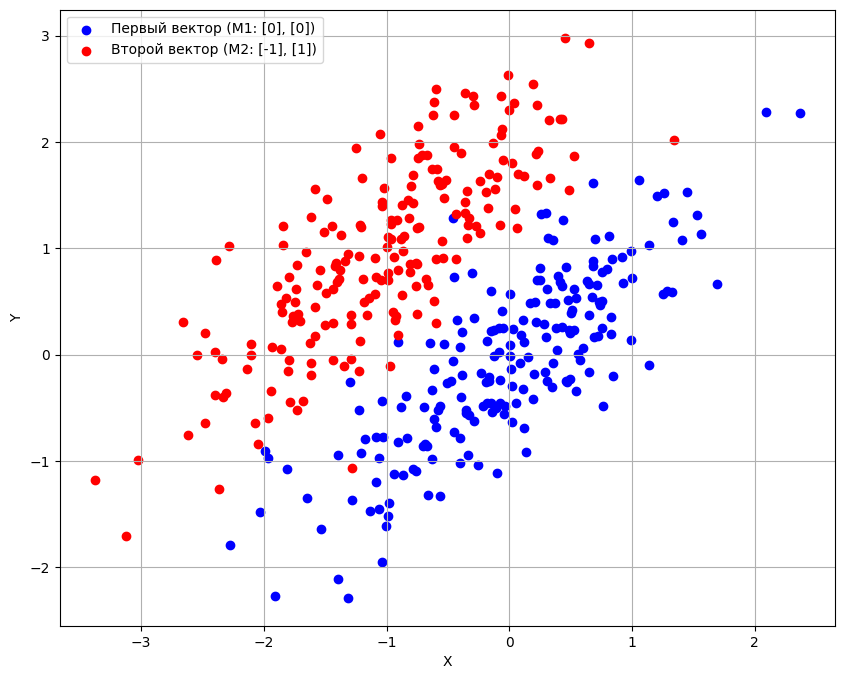

In [6]:
def generate_normal_sample(M, B, N):
    sample = np.zeros((2, N))

    for i in range(N):
        vector = generate_random_vectors(M, B)
        sample[0, i] = vector[0, 0]
        sample[1, i] = vector[1, 0]  

    return sample


N = 200

sample1 = generate_normal_sample(M1, B, N)
sample2 = generate_normal_sample(M2, B, N)

plt.figure(figsize=(10, 8))
plt.scatter(sample1[0, :], sample1[1, :], color='blue', label='Первый вектор (М1: [0], [0])')
plt.scatter(sample2[0, :], sample2[1, :], color='red', label='Второй вектор (М2: [-1], [1])')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()


3. Смоделировать и изобразить графически обучающие выборки
объема N=200 для трех нормально распределенных двумерных случайных векторов с заданными математическими ожиданиями и с неравными корреляционными матрицами, которые выбрать самостоятельно. 

In [8]:
B1 = np.array([[0.6, 0.5], 
               [0.5, 0.7]])

B2 = np.array([[0.4, 0.3],
               [0.3, 0.5]])

B3 = np.array([[ 0.3, -0.3],
               [-0.3, 0.4]])

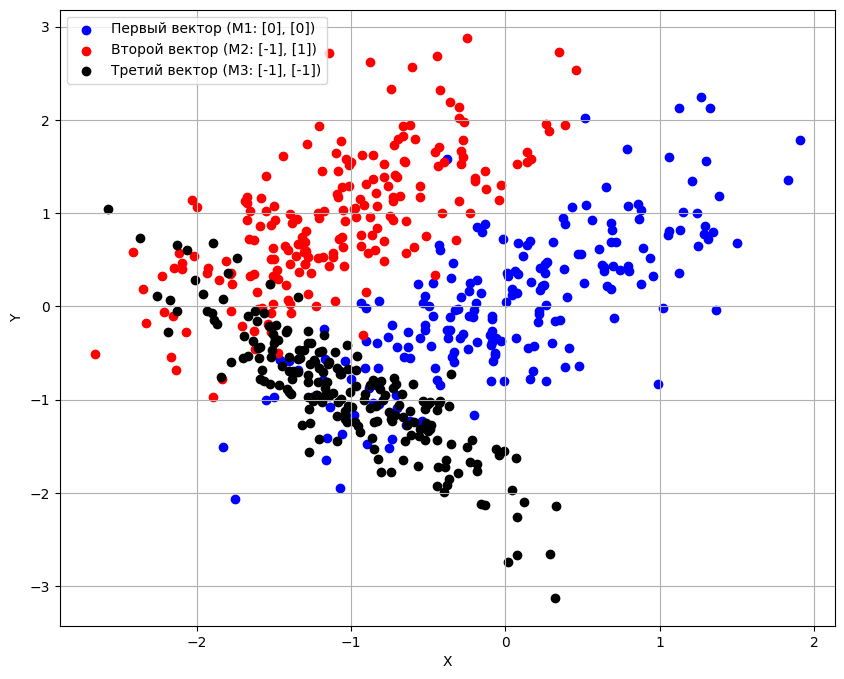

In [15]:
N=200

sample_1 = generate_normal_sample(M1, B1, N)
sample_2 = generate_normal_sample(M2, B2, N)
sample_3 = generate_normal_sample(M3, B3, N)

plt.figure(figsize=(10, 8))
plt.scatter(sample_1[0, :], sample_1[1, :], color='blue', label='Первый вектор (М1: [0], [0])')
plt.scatter(sample_2[0, :], sample_2[1, :], color='red', label='Второй вектор (М2: [-1], [1])')
plt.scatter(sample_3[0, :], sample_3[1, :], color='black', label='Третий вектор (М3: [-1], [-1])')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

4. На основании полученных выборок найти точечные оценки
параметров нормального закона для каждого из распределений. 

In [10]:
print(B1)

print(B2)

print(B3)

[[0.6 0.5]
 [0.5 0.7]]
[[0.4 0.3]
 [0.3 0.5]]
[[ 0.3 -0.3]
 [-0.3  0.4]]


In [11]:
def get_mean(X):
    rows, columns = X.shape
    mean = np.zeros((rows, 1))
    
    for i in range(rows):
        mean[i] = np.sum(X[i, :]) / columns
    
    return mean

def get_covariance(X):
    rows, columns = X.shape
    mean = get_mean(X)

    X_centered = X - mean
    
    covariance = np.zeros((rows, rows))

    for i in range(rows):
        for j in range(rows):
            covariance[i, j] = np.sum(X_centered[i, :] * X_centered[j, :]) / (columns)

    return covariance

def dist_mahalanobis(M1, M2, B):
    #if np.array_equal(B1, B2) == True:
    #    B = B1
    #else:
    #    B = (B1 + B2) / 2

    M = M2 - M1
    B_inv = np.linalg.inv(B)
    return np.dot(np.dot(M.T, B_inv), M)


def dist_bhatacharya(M1, M2, B1, B2):
    B = (B1 + B2) / 2
    
    M = M2 - M1
    B_inv = np.linalg.inv(B)

    term1 = 0.25 * np.dot(np.dot(M.T , B_inv), M)

    det_B = np.linalg.det(B)
    det_B1 = np.linalg.det(B1)
    det_B2 = np.linalg.det(B2)
    
    term2 = 0.5 * np.log(det_B / np.sqrt(det_B1 * det_B2))

    return term1 + term2

In [ ]:
#Для пары с одинаковыми дисперсиями
M_sample1 = get_mean(sample1)
M_sample2 = get_mean(sample2)

B_sample1 = get_covariance(sample1)

mahalanobis_sample = dist_mahalanobis(M_sample1, M_sample2, B_sample1)
bhatacharya_sample = dist_bhatacharya(M_sample1, M_sample2, B_sample1)

print(f"Математическое ожидание первой выборки:\n {M_sample1}")
print(f"Математическое ожидание второй выборки:\n {M_sample2}")

print(f"Ковариационная матрица первой выборки:\n {B_sample1}")


print(f"Расстояние Махалонобиса:\n {mahalanobis_sample}")
#print(f"Расстояние Бхатачария:\n {bhatacharya_sample}")

Математическое ожидание первой выборки:
 [[0.04891823]
 [0.06400225]]
Математическое ожидание второй выборки:
 [[-1.01464919]
 [ 0.99175943]]
Ковариационная матрица первой выборки:
 [[0.6044612 0.5127882]
 [0.5127882 0.697424 ]]
Расстояние Махалонобиса:
 [[14.63400532]]


In [16]:
#Для тройки с разными дисперсиями
M_sample_1 = get_mean(sample_1)
M_sample_2 = get_mean(sample_2)
M_sample_3 = get_mean(sample_3)

B_sample_1 = get_covariance(sample_1)
B_sample_2 = get_covariance(sample_2)
B_sample_3 = get_covariance(sample_3)

bhatacharya_sample_1 = dist_bhatacharya(M_sample_1, M_sample_2, B_sample_1, B_sample_2)
bhatacharya_sample_2 = dist_bhatacharya(M_sample_2, M_sample_3, B_sample_2, B_sample_3)
bhatacharya_sample_3 = dist_bhatacharya(M_sample_1, M_sample_3, B_sample_1, B_sample_3)

print(f"Математическое ожидание первой выборки:\n {M_sample_1}")
print(f"Математическое ожидание второй выборки:\n {M_sample_2}")
print(f"Математическое ожидание третьей выборки:\n {M_sample_3}")

print(f"Ковариационная матрица первой выборки:\n {B_sample_1}")
print(f"Ковариационная матрица второй выборки:\n {B_sample_2}")
print(f"Ковариационная матрица третьей выборки:\n {B_sample_3}")

#mahalanobis_sample_1 = dist_mahalanobis(M_sample_1, M_sample_2, B_sample_1)
#mahalanobis_sample_2 = dist_mahalanobis(M_sample_2, M_sample_3, B_sample_2)
#mahalanobis_sample_3 = dist_mahalanobis(M_sample_1, M_sample_3, B_sample_1)

Математическое ожидание первой выборки:
 [[0.00684548]
 [0.02317938]]
Математическое ожидание второй выборки:
 [[-1.09788172]
 [ 0.91883984]]
Математическое ожидание третьей выборки:
 [[-1.03382028]
 [-0.9147874 ]]
Ковариационная матрица первой выборки:
 [[0.56067687 0.44142919]
 [0.44142919 0.62733253]]
Ковариационная матрица второй выборки:
 [[0.37732124 0.30797586]
 [0.30797586 0.53586747]]
Ковариационная матрица третьей выборки:
 [[ 0.31834202 -0.31972666]
 [-0.31972666  0.42447259]]


In [ ]:
#print(f"Расстояние Махалонобиса первой и второй выборки:\n {mahalanobis_sample_1}")
#print(f"Расстояние Махалонобиса второй и третьей выборки:\n {mahalanobis_sample_2}")
#print(f"Расстояние Махалонобиса первой и третьей выборки:\n {mahalanobis_sample_3}")

print(f"Расстояние Бхатачария первой и второй выборки:\n {bhatacharya_sample_1}")
print(f"Расстояние Бхатачария второй и третьей выборки:\n {bhatacharya_sample_2}")
print(f"Расстояние Бхатачария первой и третьей выборки:\n {bhatacharya_sample_3}")

Расстояние Махалонобиса первой и второй выборки:
 [[13.93547146]]
Расстояние Махалонобиса второй и третьей выборки:
 [[9.03143276]]
Расстояние Махалонобиса первой и третьей выборки:
 [[2.8237461]]
Расстояние Бхатачария первой и второй выборки:
 [[3.51208188]]
Расстояние Бхатачария второй и третьей выборки:
 [[2.78334727]]
Расстояние Бхатачария первой и третьей выборки:
 [[1.29780098]]


In [17]:
np.save('class1_normal_equal_cov.npy', sample1)
np.save('class2_normal_equal_cov.npy', sample2) 
np.save('class1_normal_unequal_cov.npy', sample_1)
np.save('class2_normal_unequal_cov.npy', sample_2)
np.save('class3_normal_unequal_cov.npy', sample_3)